![](image.jpg)

Humans not only take debts to manage necessities. A country may also take debt to manage its economy. For example, infrastructure spending is one costly ingredient required for a country's citizens to lead comfortable lives. The World Bank is the organization that provides debt to countries.

In this project, you are going to analyze international debt data collected by The World Bank. The dataset contains information about the amount of debt (in USD) owed by developing countries across several categories. You are going to find the answers to the following questions:

- What is the number of distinct countries present in the database?
- What country has the highest amount of debt?
- What country has the lowest amount of repayments?

Below is a description of the table you will be working with:

## `international_debt` table

| Column | Definition | Data Type |
|-|-|-|
|country_name|Name of the country|`varchar`|
|country_code|Code representing the country|`varchar`|
|indicator_name|Description of the debt indicator|`varchar`|
|indicator_code|Code representing the debt indicator|`varchar`|
|debt|Value of the debt indicator for the given country (in current US dollars)|`float`|

You will execute SQL queries to answer three questions, as listed in the instructions.

In [2]:
SELECT * 
FROM international_debt

,country_name,country_code,indicator_name,indicator_code,debt
0,Afghanistan,AFG,"Disbursements on external debt, long-term (DIS...",DT.DIS.DLXF.CD,72894453.7
1,Afghanistan,AFG,"Interest payments on external debt, long-term ...",DT.INT.DLXF.CD,53239440.1
2,Afghanistan,AFG,"PPG, bilateral (AMT, current US$)",DT.AMT.BLAT.CD,61739336.9
3,Afghanistan,AFG,"PPG, bilateral (DIS, current US$)",DT.DIS.BLAT.CD,49114729.4
4,Afghanistan,AFG,"PPG, bilateral (INT, current US$)",DT.INT.BLAT.CD,39903620.1
...,...,...,...,...,...
2352,Zimbabwe,ZWE,"PPG, official creditors (AMT, current US$)",DT.AMT.OFFT.CD,98492119.9
2353,Zimbabwe,ZWE,"PPG, official creditors (DIS, current US$)",DT.DIS.OFFT.CD,44396033.7
2354,Zimbabwe,ZWE,"PPG, official creditors (INT, current US$)",DT.INT.OFFT.CD,15761660.0
2355,Zimbabwe,ZWE,"Principal repayments on external debt, long-te...",DT.AMT.DLXF.CD,461632253.7


In [4]:
-- count distinct countries

-- Define a query named 'num_distinct_countries'
WITH num_distinct_countries AS (
    
    -- Select distinct countries, count them, and provide output as total_distinct_countries, in one row and column
    SELECT 
        COUNT(DISTINCT country_name) AS total_distinct_countries
    FROM 
        international_debt
)

-- Select the result from the query
SELECT * 
FROM num_distinct_countries;



,total_distinct_countries
0,124


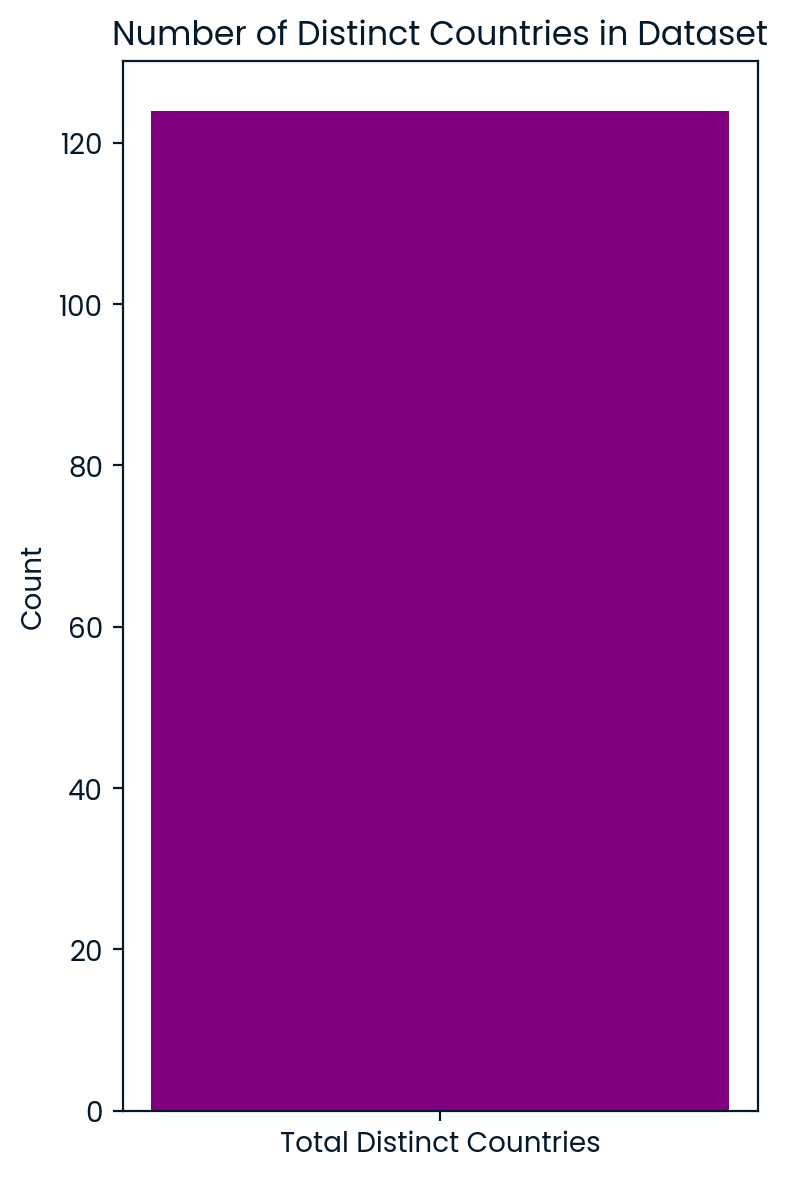

In [32]:
import pandas as pd
import matplotlib.pyplot as plt


# Step 1: Count the number of distinct countries
num_distinct_countries_df = original_df['country_name'].nunique()

# Step 2: Visualize using a simple bar chart
plt.figure(figsize=(4, 6))
plt.bar(['Total Distinct Countries'], [num_distinct_countries_df], color='purple')
plt.title('Number of Distinct Countries in Dataset')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
-- To calculate highest total disbursements for each country where indicator_code = DT.DIS.DLXF.CD, and include the country's repayment amount where indicator_code = DT.AMT.DLXF.CD

-- CODE, using a CTE...
-- Define a query named 'highest_disbursements'

WITH highest_disbursements AS (
	SELECT country_name,
		SUM(CASE 
				WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_disbursements,
		SUM(CASE 
				WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_repayments
	
	FROM international_debt
	GROUP BY country_name
	
)
SELECT * 
FROM highest_disbursements
ORDER BY total_disbursements DESC
LIMIT 20;


,country_name,total_disbursements,total_repayments
0,Least developed countries: UN classification,4.016077e+10,2.519703e+10
1,IDA only,3.453119e+10,2.048329e+10
2,South Asia,2.930622e+10,4.875630e+10
3,Cameroon,1.818666e+10,1.040481e+10
4,China,1.569256e+10,9.621862e+10
5,India,1.100555e+10,3.192351e+10
6,Angola,1.092402e+10,1.106705e+10
7,"Egypt, Arab Rep.",9.552207e+09,9.692114e+09
8,Bangladesh,9.050558e+09,2.077015e+09
9,Vietnam,6.494122e+09,8.873506e+09


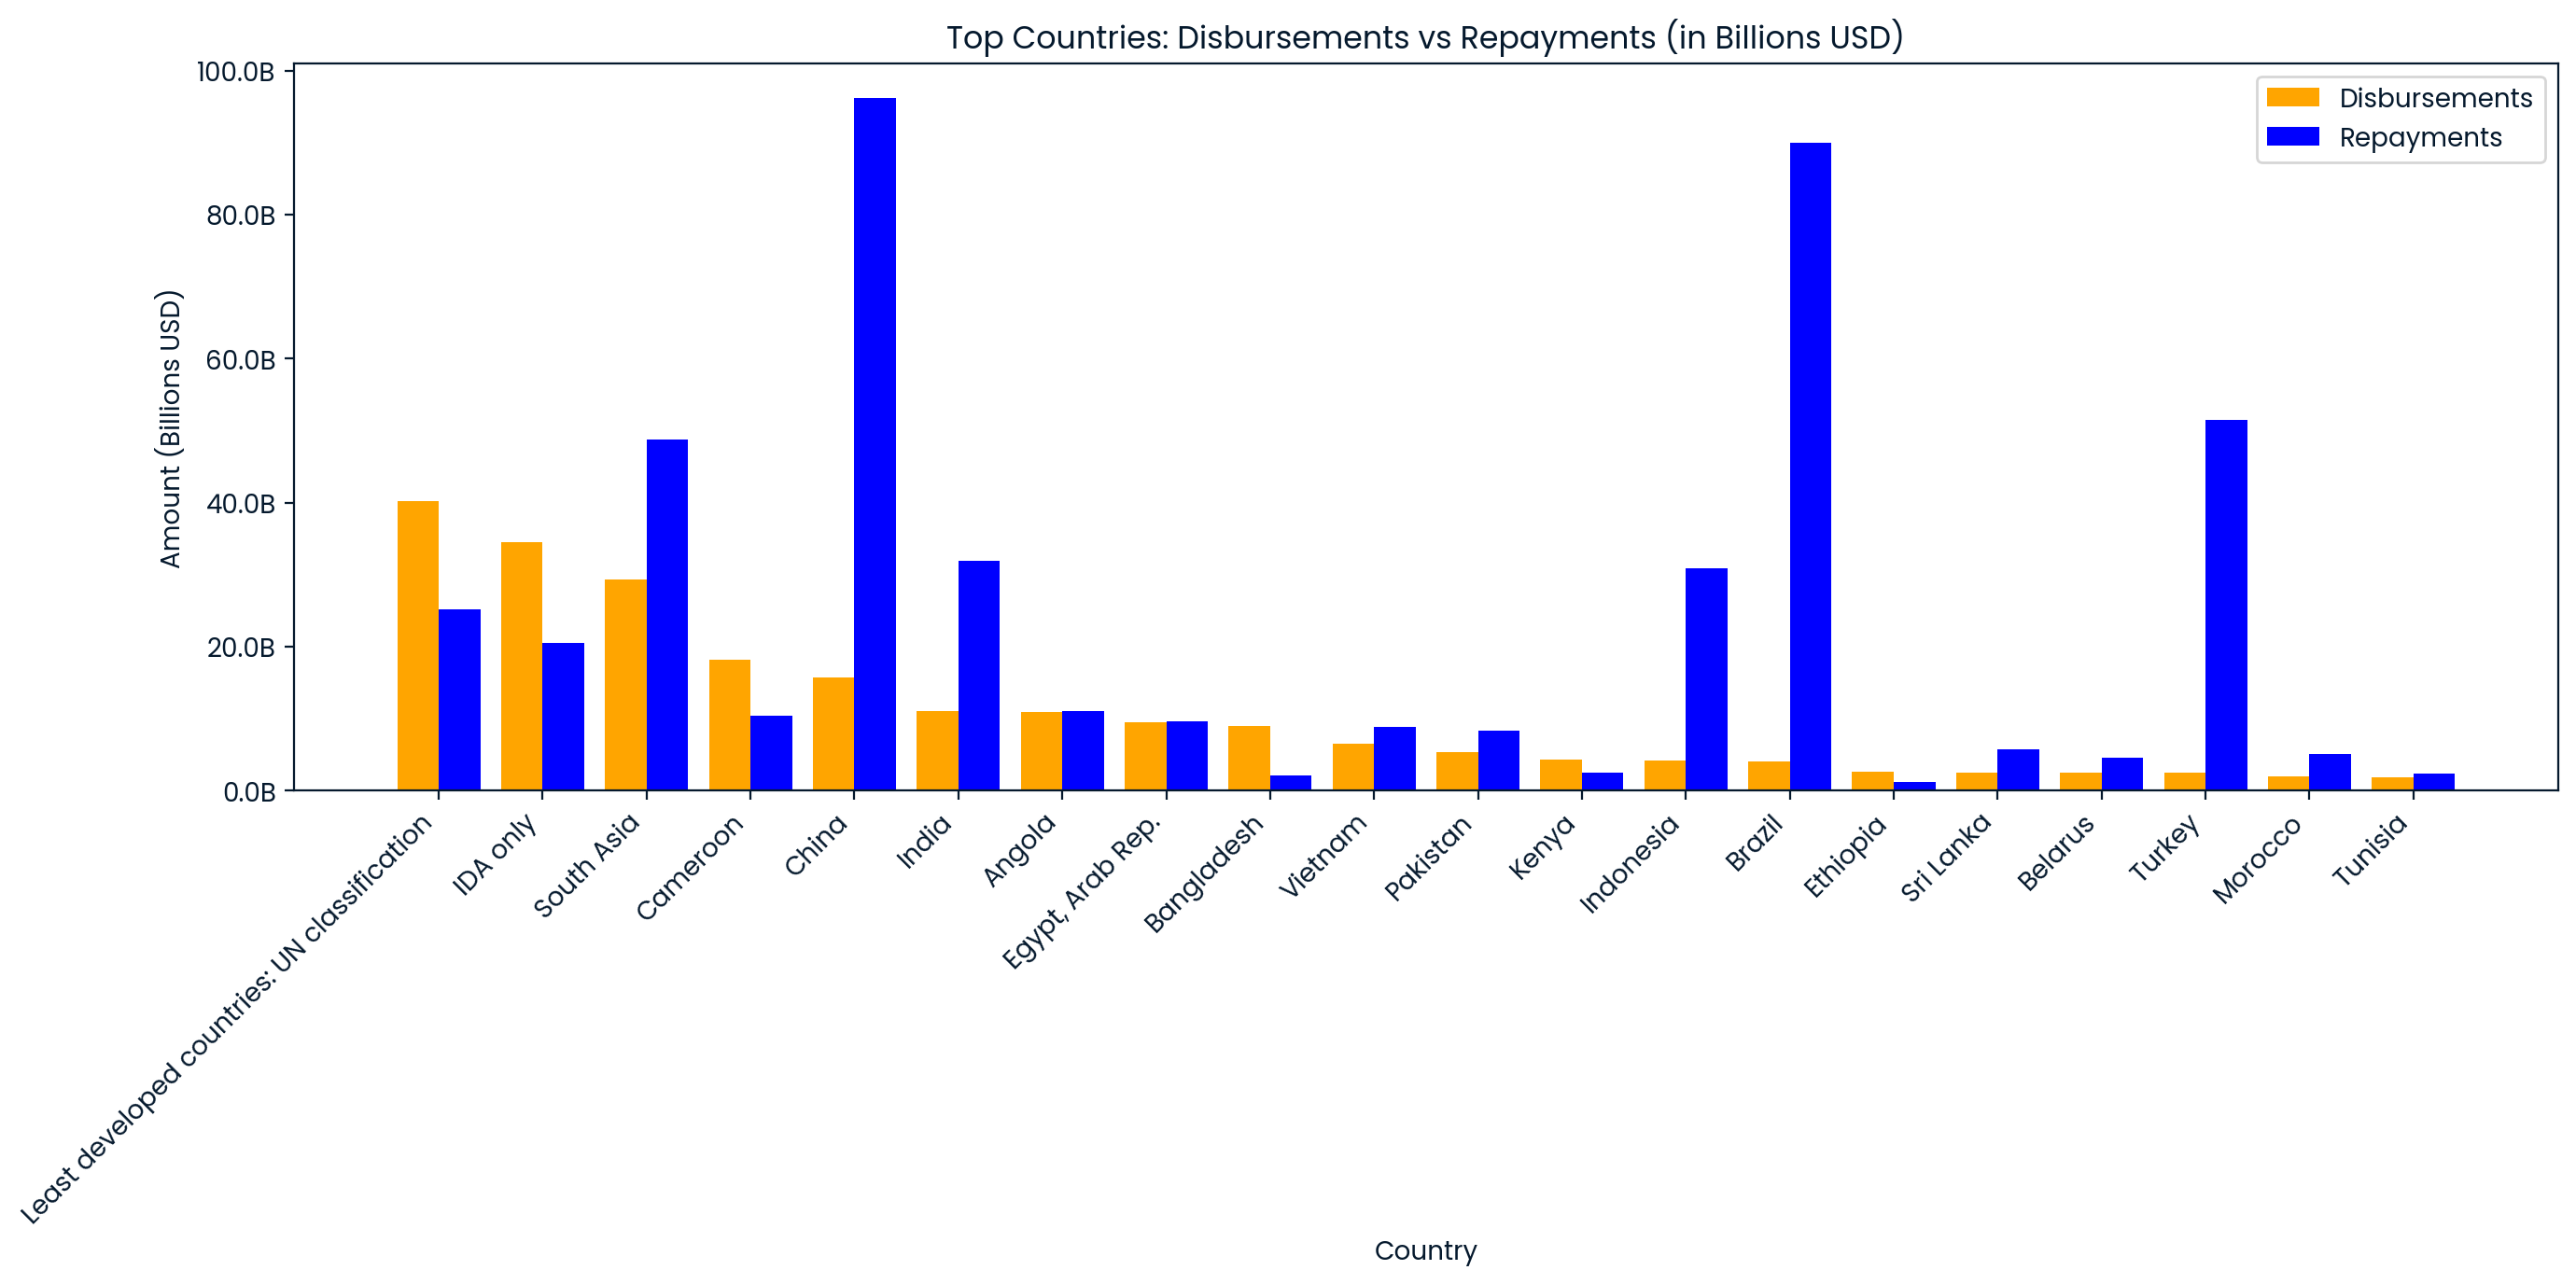

In [7]:
import matplotlib.ticker as ticker

plt.figure(figsize=(14, 7))
bar_width = 0.4
x = range(len(highest_disbursements_df))

# Plot disbursements
plt.bar(x, highest_disbursements_df['total_disbursements'], 
        width=bar_width, label='Disbursements', color='orange')

# Plot repayments next to disbursements
plt.bar(
    [i + bar_width for i in x],
    highest_disbursements_df['total_repayments'],
    width=bar_width, label='Repayments', color='blue'
)

# X-axis labels
plt.xticks(
    [i + bar_width / 2 for i in x],
    highest_disbursements_df['country_name'],
    rotation=45, ha='right'
)

# Y-axis formatting: billions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
plt.gca().yaxis.set_major_formatter(formatter)

# Labels and title
plt.ylabel('Amount (Billions USD)')
plt.xlabel('Country')
plt.title('Top Countries: Disbursements vs Repayments (in Billions USD)')
plt.legend()

# Tight layout for better spacing
plt.tight_layout()

# Show plot
plt.show()

In [20]:
-- To calculate lowest total disbursements for each country where indicator_code = DT.DIS.DLXF.CD, and include the country's repayment amount where indicator_code = DT.AMT.DLXF.CD

-- CODE, using a CTE...
-- Define a query named 'lowest_disbursements'

WITH lowest_disbursements AS (
	SELECT country_name,
		SUM(CASE 
				WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_disbursements,
		SUM(CASE 
				WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_repayments
	
	FROM international_debt
	GROUP BY country_name
)
SELECT * 
FROM lowest_disbursements
ORDER BY total_disbursements ASC
LIMIT 5; --20 if necessary


,country_name,total_disbursements,total_repayments
0,Turkmenistan,0.0,29132060.9
1,Somalia,2456971.6,32985034.3
2,Tonga,5529604.8,10369910.6
3,Eritrea,7203213.6,31110077.8
4,Solomon Islands,8645249.9,30749703.9


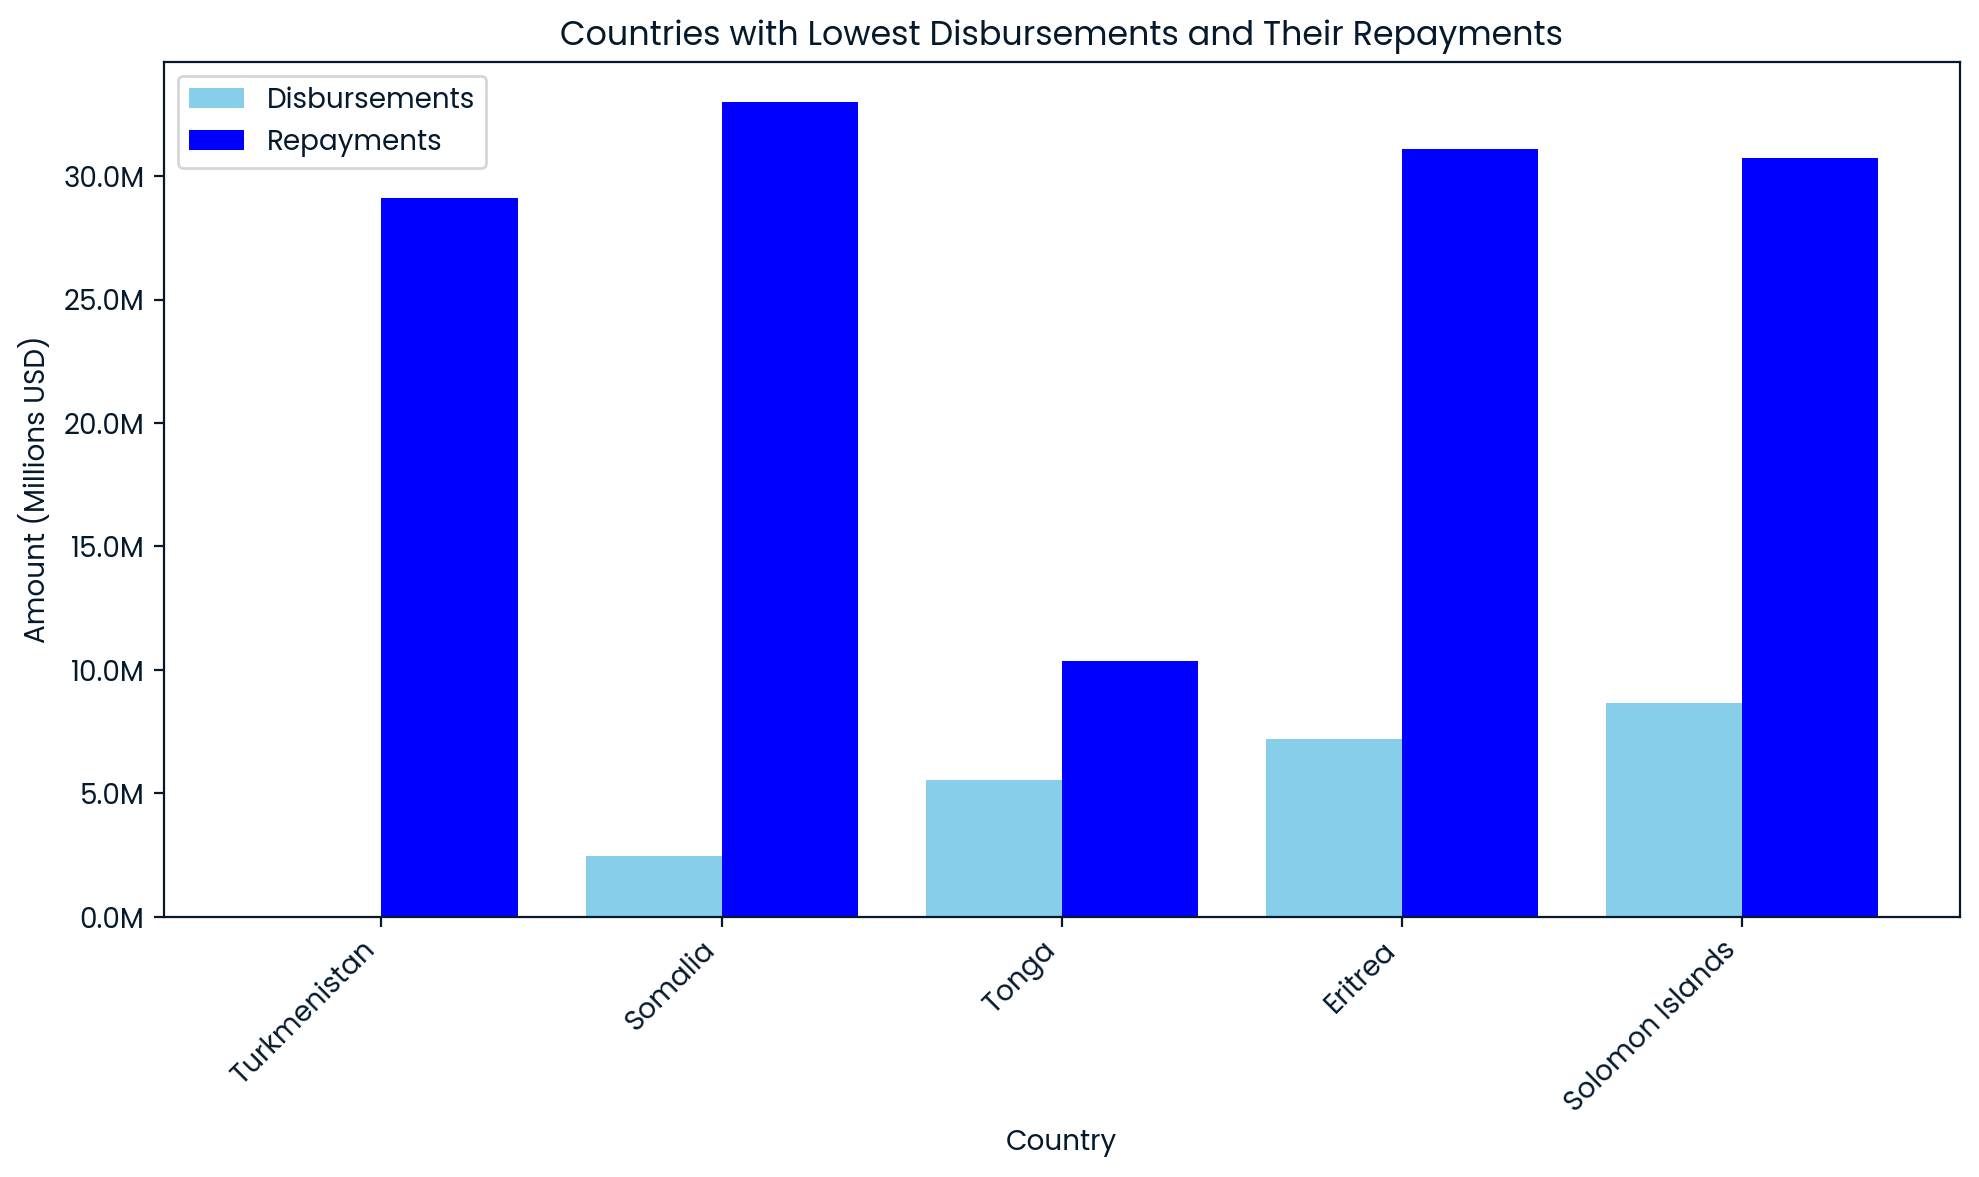

In [21]:
plt.figure(figsize=(10, 6))

bar_width = 0.4
x = range(len(lowest_disbursements_df))  # Positions for bars

# Plot disbursements (light blue)
plt.bar(x, lowest_disbursements_df['total_disbursements'], 
        width=bar_width, label='Disbursements', color='skyblue')

# Plot repayments (light red), shifted right
plt.bar([i + bar_width for i in x], lowest_disbursements_df['total_repayments'], 
        width=bar_width, label='Repayments', color='blue')

# Add country names below the bars
plt.xticks([i + bar_width / 2 for i in x], 
           lowest_disbursements_df['country_name'], 
           rotation=45, ha='right')

# Format y-axis in millions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Amount (Millions USD)')
plt.title('Countries with Lowest Disbursements and Their Repayments')
plt.legend()

plt.tight_layout()
plt.show()


In [33]:
-- lowest_principal_repayment 
-- CODE, using a CTE...
-- Define a query named 'lowest_principal_repayment'

WITH lowest_principal_repayment AS (
	-- Select country_name, indicator_name and debt aliased as lowest_repayment, where indicator_name = DT.AMT.DLXF.CD, in ascending order. Limit to 5
	SELECT country_name,

		SUM(CASE 
				WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_repayments,
	
		SUM(CASE 
				WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_disbursements
	
	FROM international_debt
	GROUP BY country_name
)
SELECT * 
FROM lowest_principal_repayment
ORDER BY total_repayments ASC
LIMIT 5; -- 20 if necessary

,country_name,total_repayments,total_disbursements
0,Timor-Leste,825000.0,21799986.4
1,Sao Tome and Principe,2941396.3,10636848.5
2,Comoros,4792269.1,13460035.4
3,Guinea-Bissau,6783629.1,48265990.2
4,Tonga,10369910.6,5529604.8


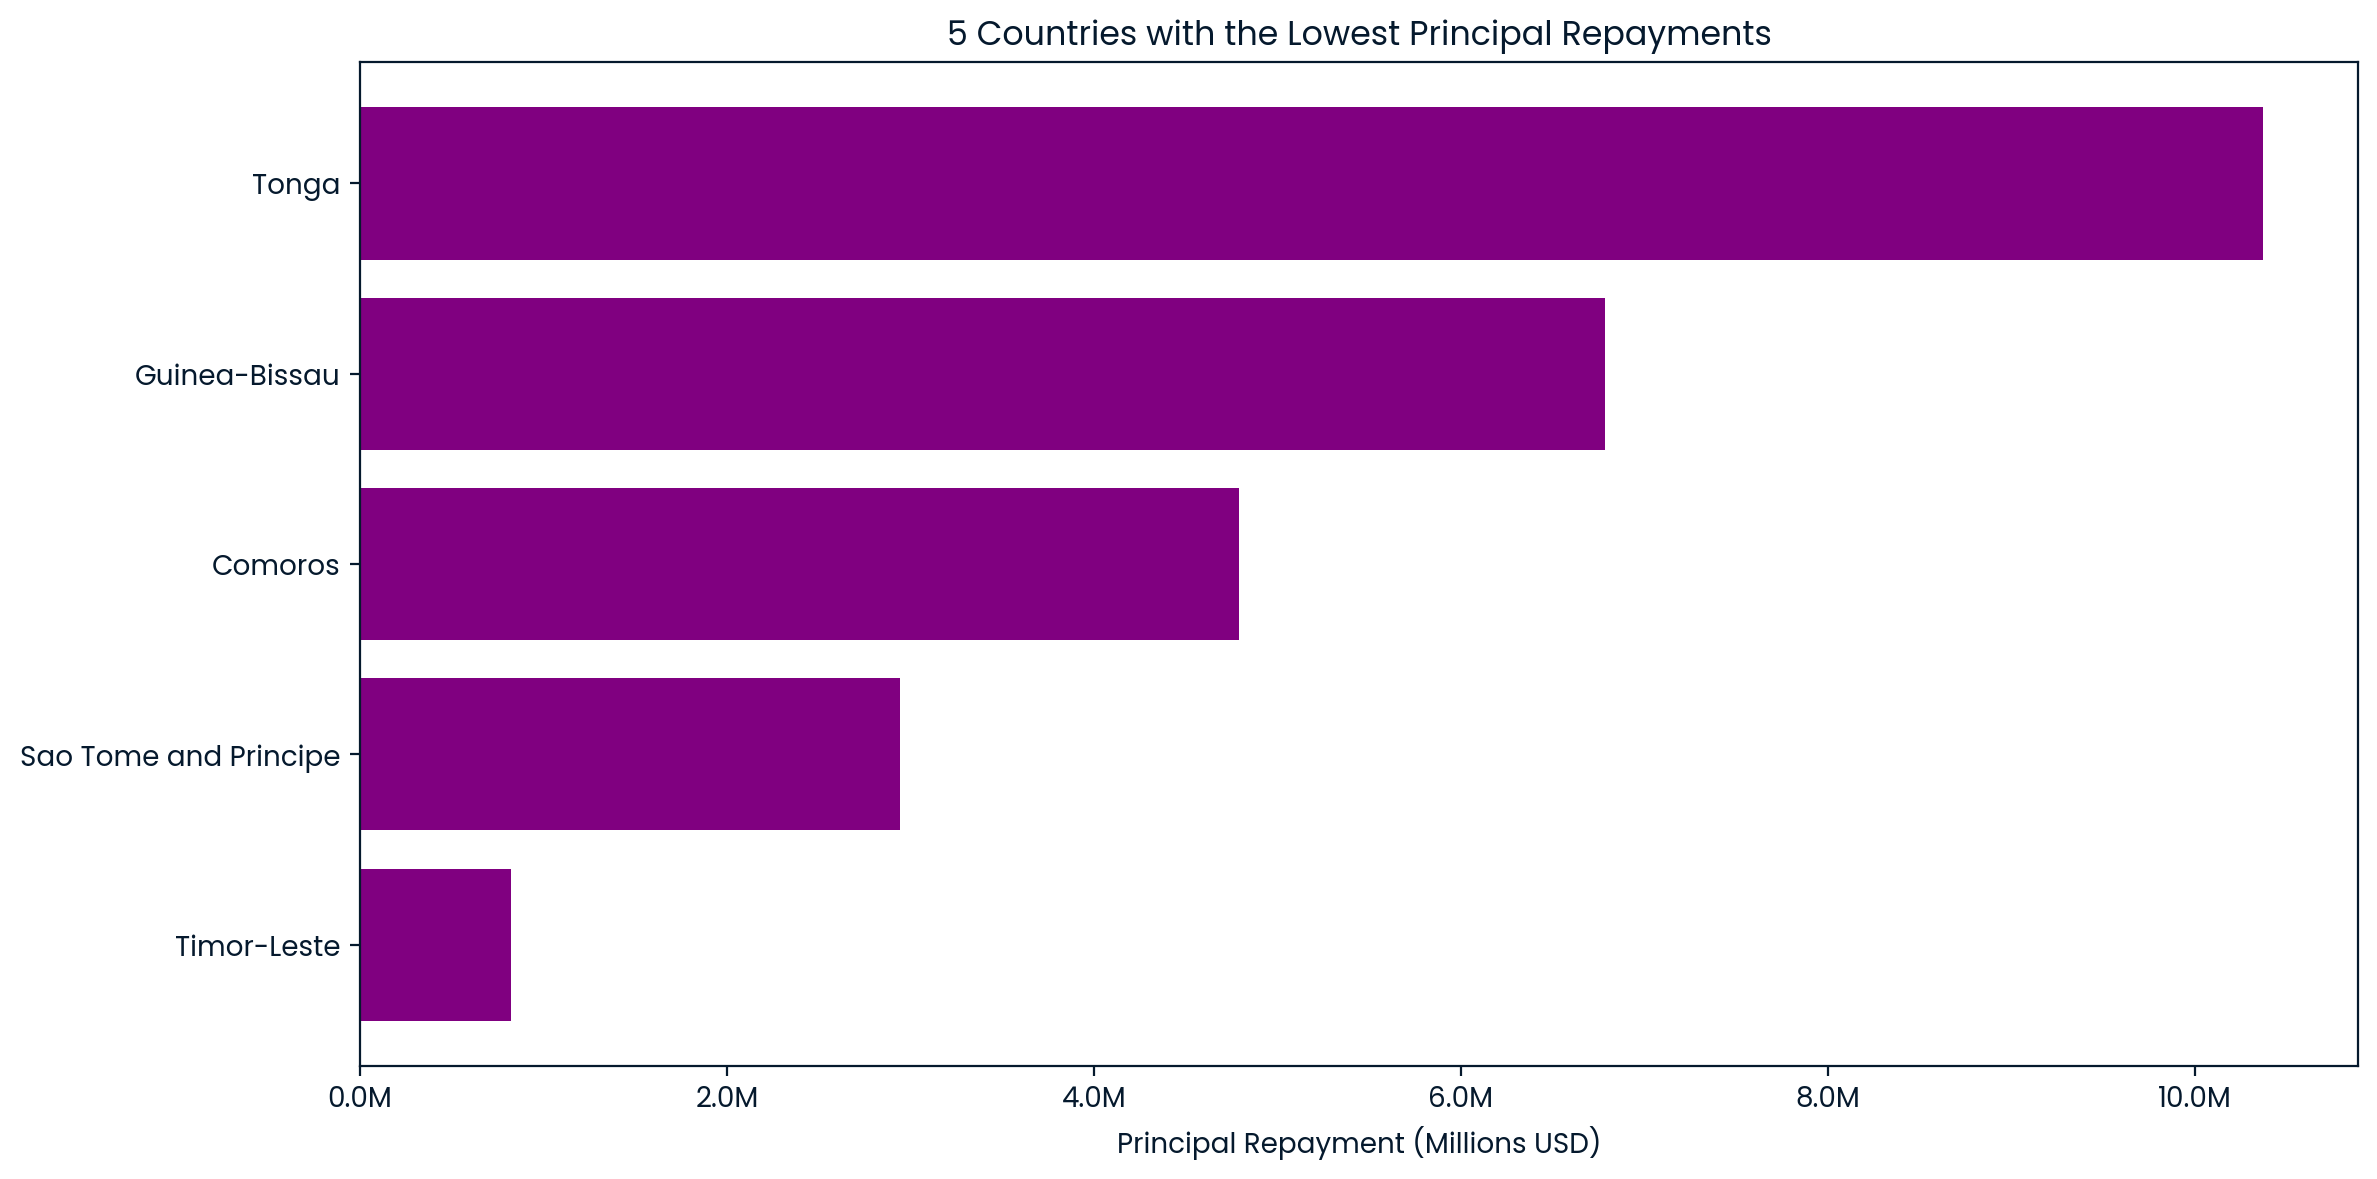

In [27]:
plt.figure(figsize=(12, 6))

# Create a horizontal bar chart
plt.barh(lowest_principal_repayment['country_name'], lowest_principal_repayment['total_repayments'], color='purple')

# Format y-axis numbers into millions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)

plt.xlabel('Principal Repayment (Millions USD)')
plt.title('5 Countries with the Lowest Principal Repayments')

plt.tight_layout()
plt.show()


In [34]:
-- CODE, using a CTE...
-- Define a query named 'highest_repayments'

WITH highest_repayments AS (
	-- Select country_name, indicator_name and debt aliased as highest_repayments, where indicator_name = DT.AMT.DLXF.CD, in ascending order. Limit to 20

	SELECT country_name, indicator_name, debt AS highest_repayments
	FROM international_debt
	WHERE indicator_code = 'DT.AMT.DLXF.CD'  -- Only principal repayments
	ORDER BY highest_repayments DESC
)
-- Select the result from the query
SELECT * 
FROM highest_repayments
Limit 20; 

,country_name,indicator_name,highest_repayments
0,China,"Principal repayments on external debt, long-te...",9.621862e+10
1,Brazil,"Principal repayments on external debt, long-te...",9.004184e+10
2,Russian Federation,"Principal repayments on external debt, long-te...",6.658976e+10
3,Turkey,"Principal repayments on external debt, long-te...",5.155503e+10
4,South Asia,"Principal repayments on external debt, long-te...",4.875630e+10
5,India,"Principal repayments on external debt, long-te...",3.192351e+10
6,Indonesia,"Principal repayments on external debt, long-te...",3.091611e+10
7,Kazakhstan,"Principal repayments on external debt, long-te...",2.748209e+10
8,Mexico,"Principal repayments on external debt, long-te...",2.521850e+10
9,Least developed countries: UN classification,"Principal repayments on external debt, long-te...",2.519703e+10


In [36]:
-- to extract countries with the lowest disbursements but highest repayments

--  Get bottom 20 countries by total disbursements
WITH bottom_20_disbursements AS (
    SELECT country_name,
           SUM(CASE WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt ELSE 0 END) AS total_disbursements
    FROM international_debt
    GROUP BY country_name
    ORDER BY total_disbursements ASC
    LIMIT 20
),

-- Get top 20 countries by total repayments
top_20_repayments AS (
    SELECT country_name,
           SUM(CASE WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt ELSE 0 END) AS total_repayments
    FROM international_debt
    GROUP BY country_name
    ORDER BY total_repayments DESC
    LIMIT 20
)

-- Countries that appear in both lists
SELECT b.country_name, 
       b.total_disbursements, 
       t.total_repayments
FROM bottom_20_disbursements b
JOIN top_20_repayments t
ON b.country_name = t.country_name;


,country_name,total_disbursements,total_repayments
0,Russian Federation,33043274.4,6.658976e+10


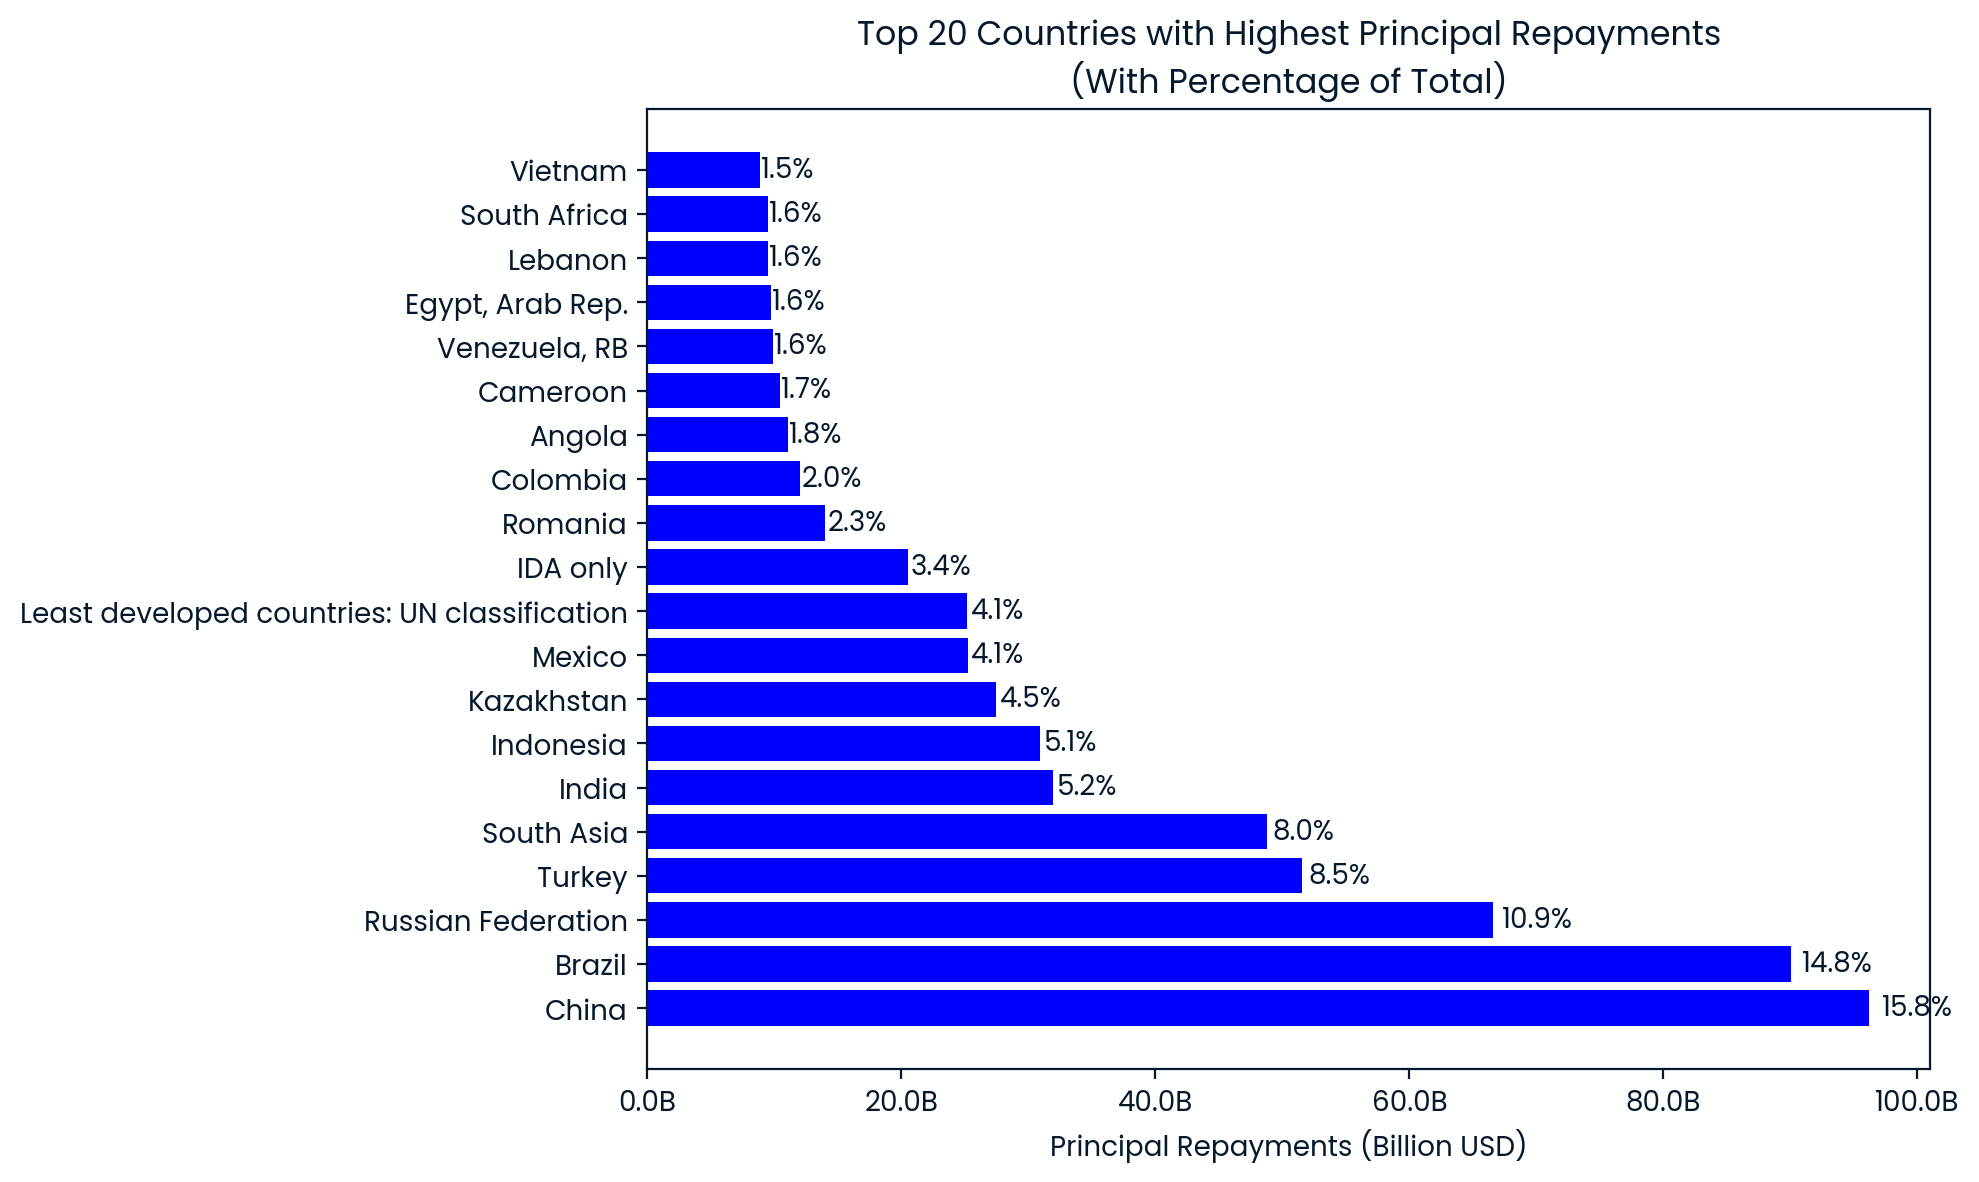

In [30]:
total_repayments = highest_repayments_df['highest_repayments'].sum()
highest_repayments_df['repayment_percentage'] = (
    highest_repayments_df['highest_repayments'] / total_repayments * 100
)

plt.figure(figsize=(10, 6))
plt.barh(highest_repayments_df['country_name'], 
         highest_repayments_df['highest_repayments'], 
         color='blue')

# Format x-axis values as billions
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
plt.gca().xaxis.set_major_formatter(formatter)

# Add value labels (repayment percentage) on each bar
for i, (value, pct) in enumerate(zip(highest_repayments_df['highest_repayments'], 
                                     highest_repayments_df['repayment_percentage'])):
    plt.text(value + 0.01 * value, i, f'{pct:.1f}%', va='center', fontsize=10)

plt.xlabel('Principal Repayments (Billion USD)')
plt.title('Top 20 Countries with Highest Principal Repayments\n(With Percentage of Total)')
plt.tight_layout()
plt.show()


In [15]:
-- select country_name, indicator_name, debt where indicator_code = 'DT.INT.DLXF.CD'

SELECT country_name, indicator_name, debt
FROM international_debt
WHERE indicator_code = 'DT.INT.DLXF.CD'
ORDER BY debt DESC
LIMIT 20;


,country_name,indicator_name,debt
0,Mexico,"Interest payments on external debt, long-term ...",1.926797e+10
1,China,"Interest payments on external debt, long-term ...",1.786655e+10
2,Brazil,"Interest payments on external debt, long-term ...",1.700165e+10
3,South Asia,"Interest payments on external debt, long-term ...",1.593156e+10
4,Russian Federation,"Interest payments on external debt, long-term ...",1.392983e+10
5,Turkey,"Interest payments on external debt, long-term ...",1.209557e+10
6,India,"Interest payments on external debt, long-term ...",1.141948e+10
7,Indonesia,"Interest payments on external debt, long-term ...",1.019010e+10
8,IDA only,"Interest payments on external debt, long-term ...",7.269409e+09
9,Least developed countries: UN classification,"Interest payments on external debt, long-term ...",7.085065e+09


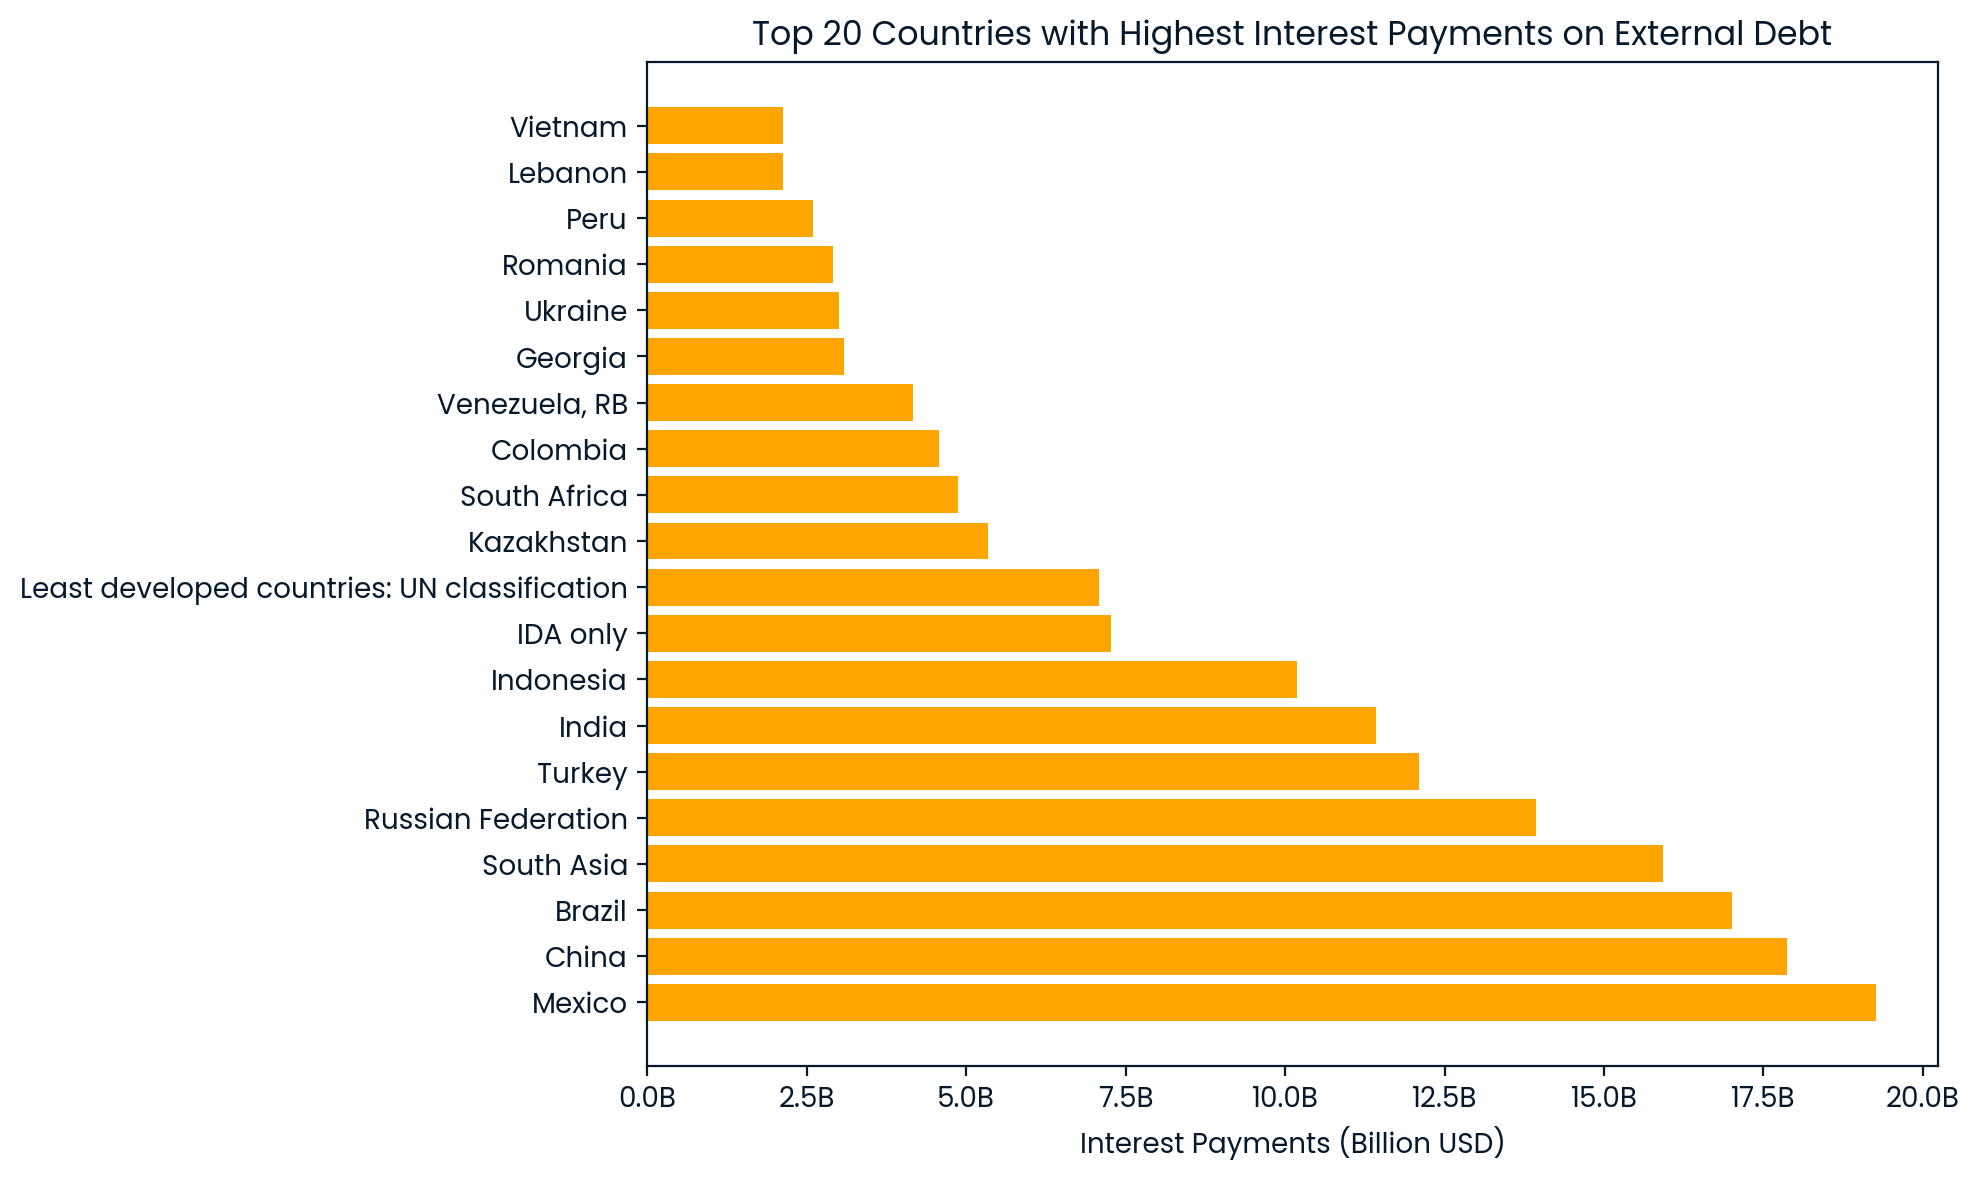

In [31]:
plt.figure(figsize=(10, 6))  # Set chart size

# Create horizontal bars for interest payments
plt.barh(highest_interest_df['country_name'], 
         highest_interest_df['debt'], 
         color='orange')

# Format x-axis values in billions (e.g., 25.3B)
formatter = ticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
plt.gca().xaxis.set_major_formatter(formatter)

# Add labels and title
plt.xlabel('Interest Payments (Billion USD)')
plt.title('Top 20 Countries with Highest Interest Payments on External Debt')

plt.tight_layout()
plt.show()


In [37]:
-- countries with highest interest payments that also fall under highest principal repayments
-- Find top 20 countries by total principal repayments

WITH top_repayment_countries AS (
    SELECT country_name
    FROM international_debt
    WHERE indicator_code = 'DT.AMT.DLXF.CD'
    ORDER BY debt DESC
    LIMIT 20
)

-- Interest payments for those countries
SELECT d.country_name, d.indicator_name, d.debt AS interest_payments
FROM international_debt d
JOIN top_repayment_countries r ON d.country_name = r.country_name
WHERE d.indicator_code = 'DT.INT.DLXF.CD'
ORDER BY d.debt DESC;


,country_name,indicator_name,interest_payments
0,Mexico,"Interest payments on external debt, long-term ...",1.926797e+10
1,China,"Interest payments on external debt, long-term ...",1.786655e+10
2,Brazil,"Interest payments on external debt, long-term ...",1.700165e+10
3,South Asia,"Interest payments on external debt, long-term ...",1.593156e+10
4,Russian Federation,"Interest payments on external debt, long-term ...",1.392983e+10
5,Turkey,"Interest payments on external debt, long-term ...",1.209557e+10
6,India,"Interest payments on external debt, long-term ...",1.141948e+10
7,Indonesia,"Interest payments on external debt, long-term ...",1.019010e+10
8,IDA only,"Interest payments on external debt, long-term ...",7.269409e+09
9,Least developed countries: UN classification,"Interest payments on external debt, long-term ...",7.085065e+09


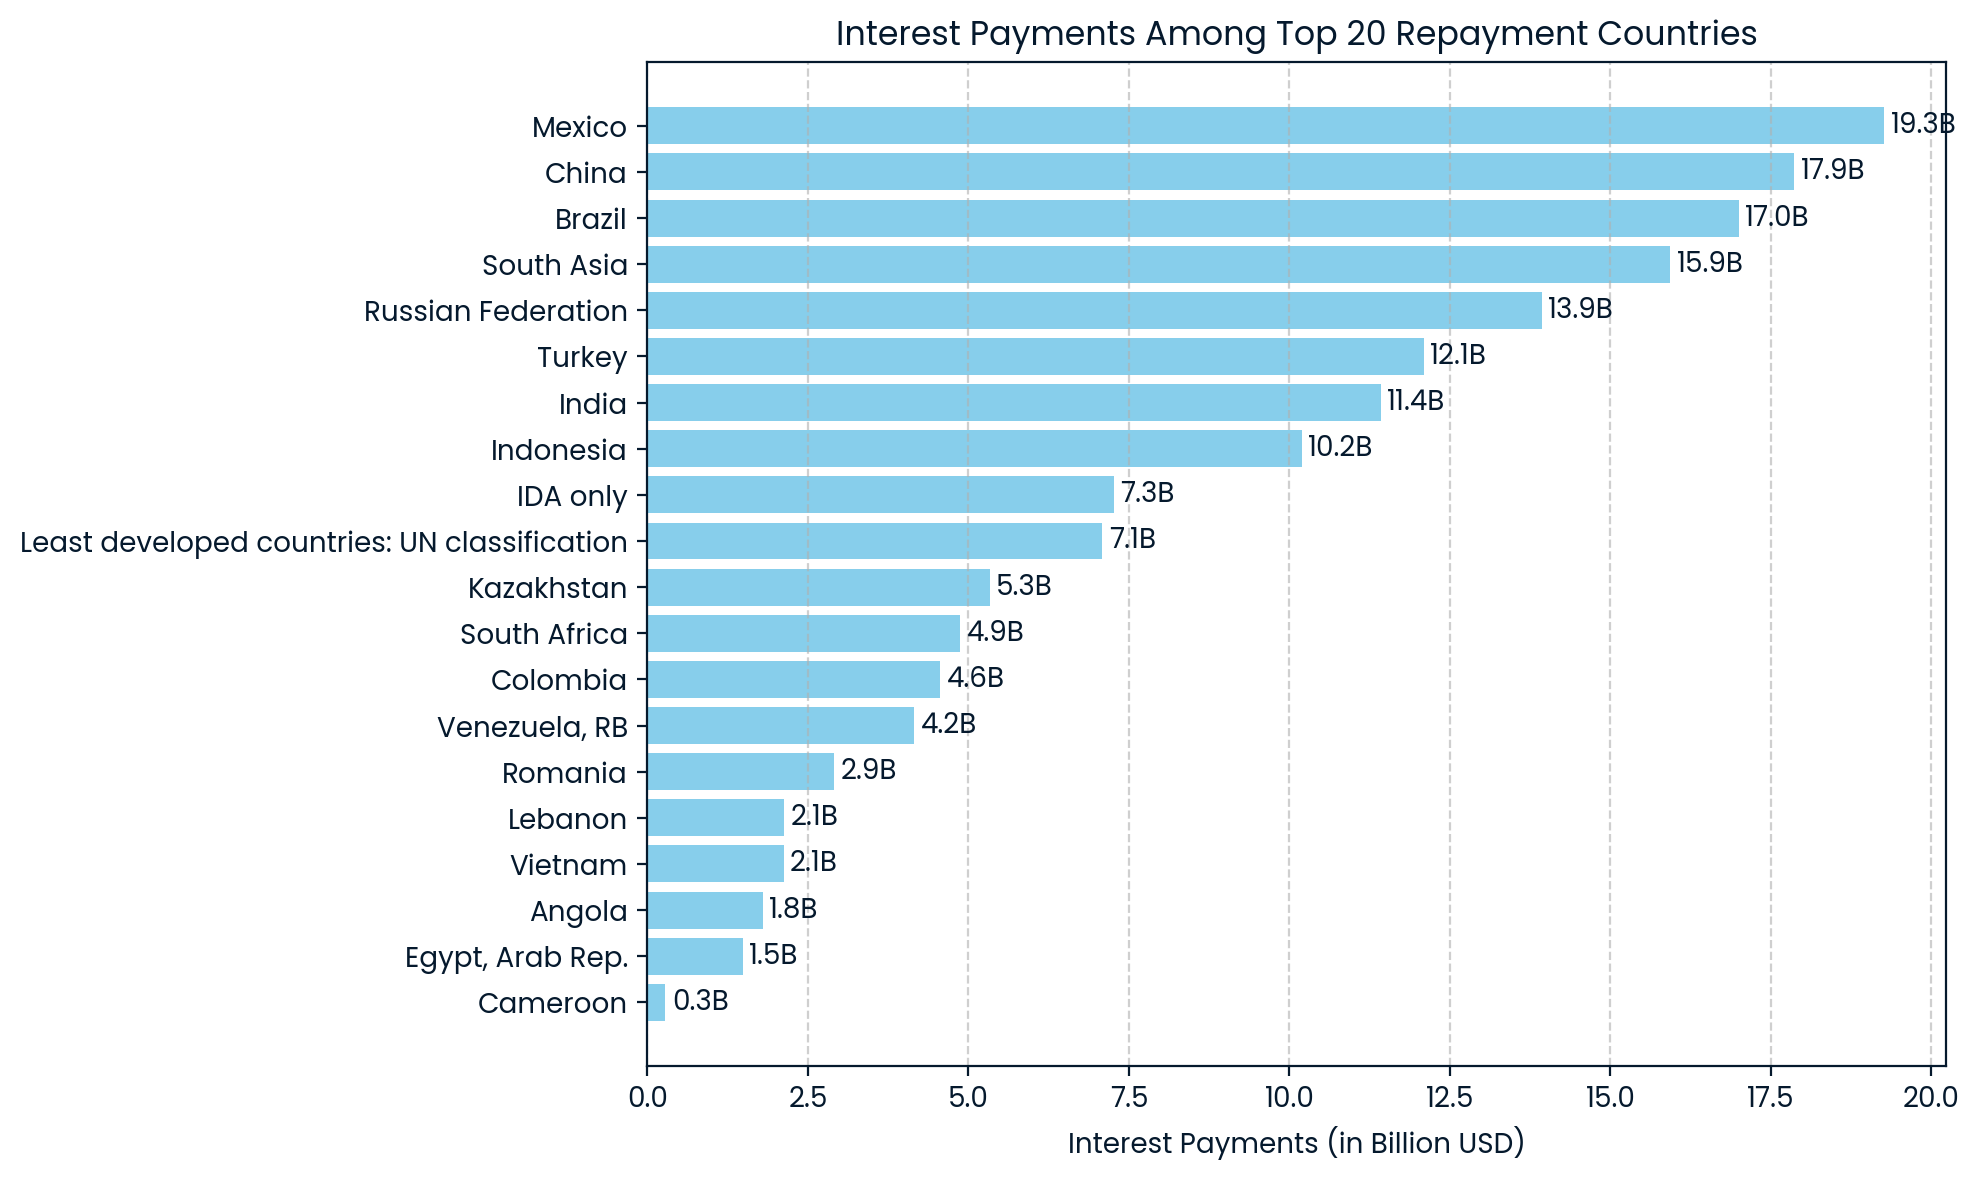

In [18]:

# Convert interest payments to billions for readability
highest_interest_in_top_repayments_df['interest_billions'] = highest_interest_in_top_repayments_df['interest_payments'] / 1e9

# Sort by interest payments descending
df_sorted = highest_interest_in_top_repayments_df.sort_values(by='interest_billions', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(df_sorted['country_name'], df_sorted['interest_billions'], color='skyblue')

# Add text labels
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}B", va='center')

# Titles and labels
plt.xlabel('Interest Payments (in Billion USD)')
plt.title('Interest Payments Among Top 20 Repayment Countries')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()


In [38]:
--Breakdown of disbursements for 5 countries with the highest and lowest disbursements
(
	SELECT country_name,
		SUM(CASE 
				WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_disbursements,
		SUM(CASE 
				WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_repayments
	
	FROM international_debt
	GROUP BY country_name
	ORDER BY total_disbursements DESC
	LIMIT 5
)

UNION ALL
		
(
	SELECT country_name,
		SUM(CASE 
				WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_disbursements,
		SUM(CASE 
				WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt
				ELSE 0
			END) AS total_repayments
	
	FROM international_debt
	GROUP BY country_name
	ORDER BY total_disbursements ASC
	LIMIT 5
);

,country_name,total_disbursements,total_repayments
0,Least developed countries: UN classification,4.016077e+10,2.519703e+10
1,IDA only,3.453119e+10,2.048329e+10
2,South Asia,2.930622e+10,4.875630e+10
3,Cameroon,1.818666e+10,1.040481e+10
4,China,1.569256e+10,9.621862e+10
5,Turkmenistan,0.000000e+00,2.913206e+07
6,Somalia,2.456972e+06,3.298503e+07
7,Tonga,5.529605e+06,1.036991e+07
8,Eritrea,7.203214e+06,3.111008e+07
9,Solomon Islands,8.645250e+06,3.074970e+07


In [22]:
SELECT 
    country_name,
    indicator_name,
    SUM(debt) AS total_disbursement
FROM international_debt
WHERE country_name IN (
    'Least developed countries: UN classification',
    'IDA only',
    'South Asia',
    'Cameroon',
    'China',
    'Turkmenistan',
    'Somalia',
    'Tonga',
    'Eritrea',
    'Solomon Islands'
)
AND indicator_code LIKE 'DT.DIS%'        -- Keep only disbursements
AND indicator_code != 'DT.DIS.DLXF.CD'   -- Exclude the total disbursement row
GROUP BY country_name, indicator_name
ORDER BY country_name, total_disbursement DESC;


,country_name,indicator_name,total_disbursement
0,Cameroon,"PPG, official creditors (DIS, current US$)",1.794058e+10
1,Cameroon,"PPG, bilateral (DIS, current US$)",1.709054e+10
2,Cameroon,"PPG, multilateral (DIS, current US$)",8.500368e+08
3,Cameroon,"PPG, private creditors (DIS, current US$)",2.460810e+08
4,Cameroon,"PPG, commercial banks (DIS, current US$)",1.961671e+08
5,Cameroon,"PPG, other private creditors (DIS, current US$)",4.991390e+07
6,China,"PPG, private creditors (DIS, current US$)",4.111062e+09
7,China,"PPG, commercial banks (DIS, current US$)",3.777050e+09
8,China,"PPG, multilateral (DIS, current US$)",3.079501e+09
9,China,"PPG, official creditors (DIS, current US$)",3.079501e+09


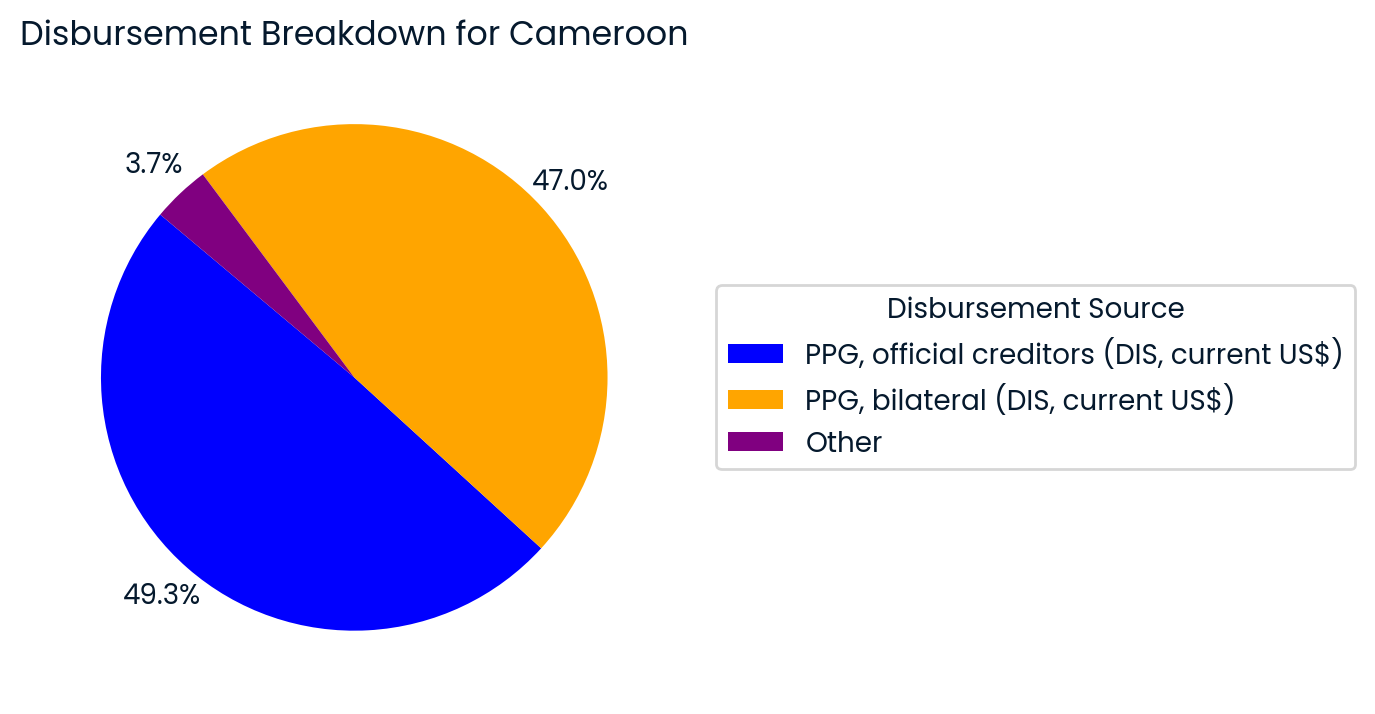

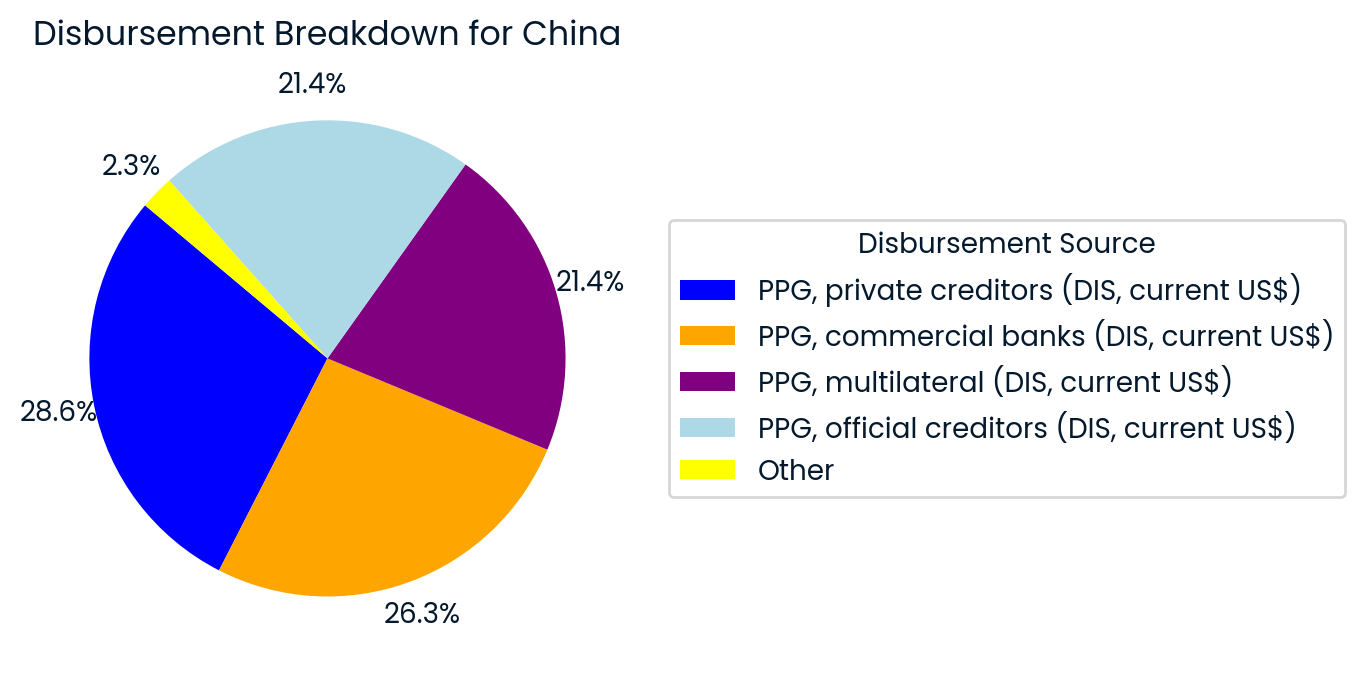

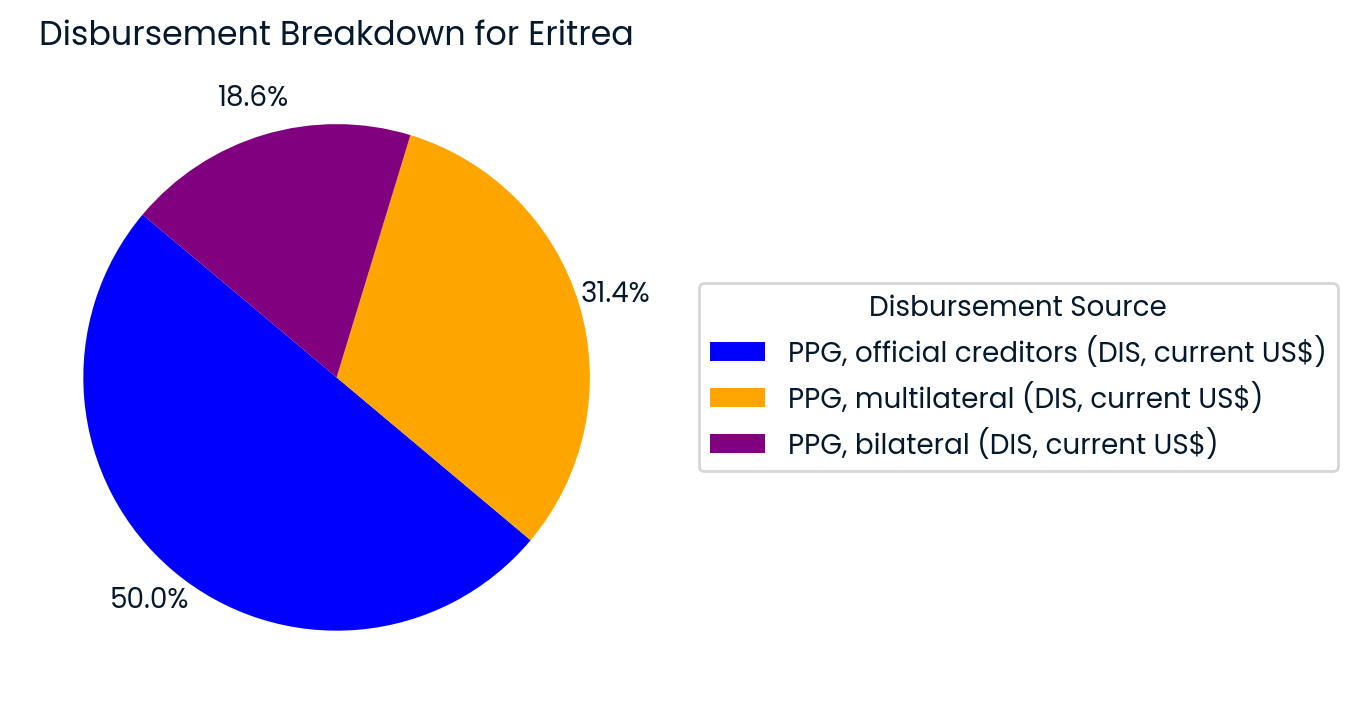

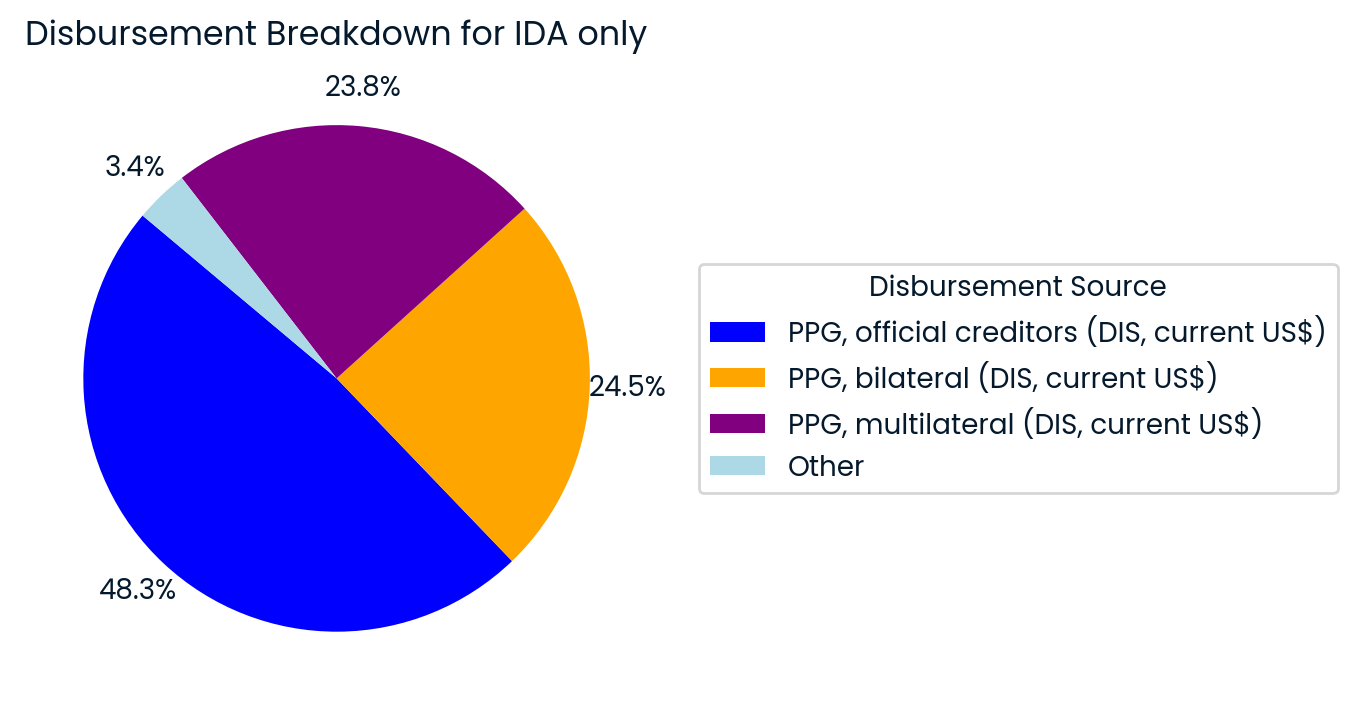

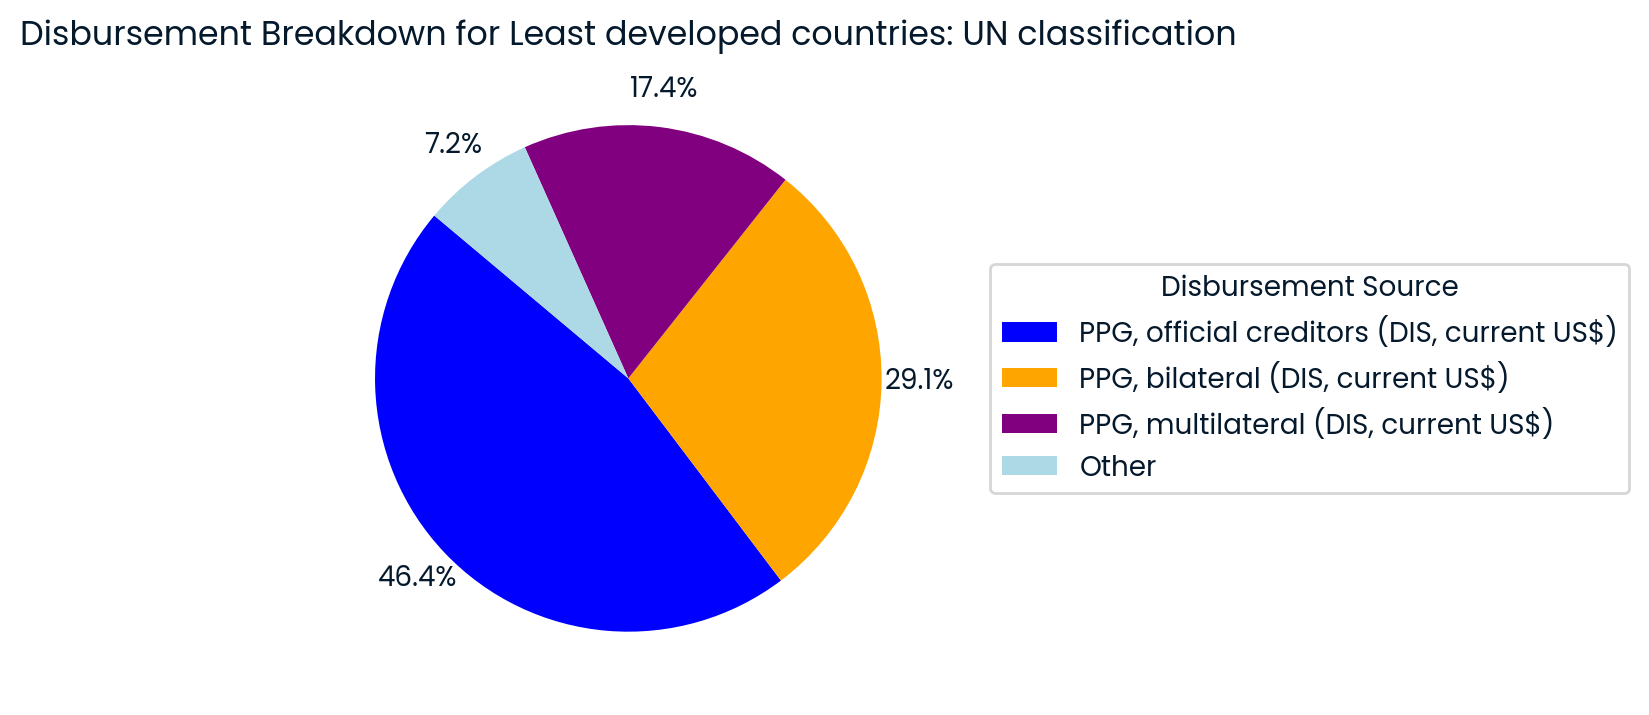

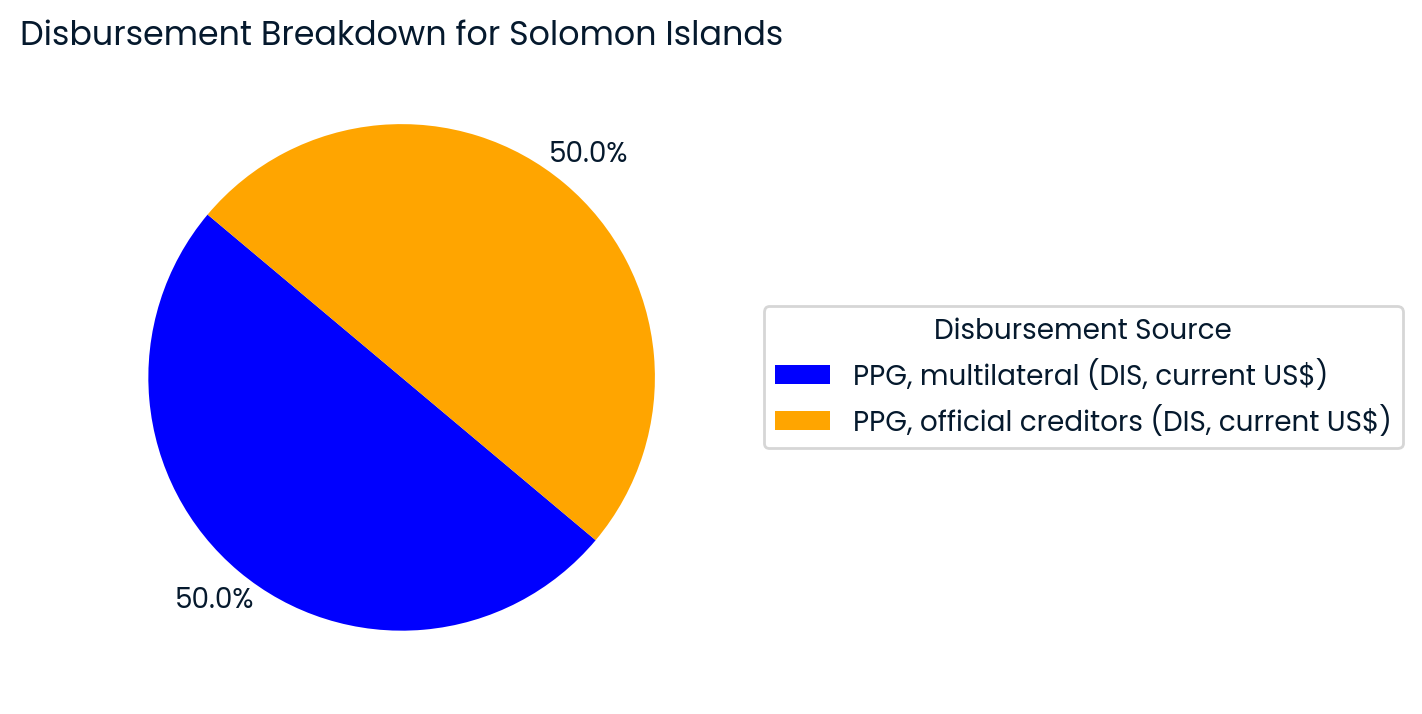

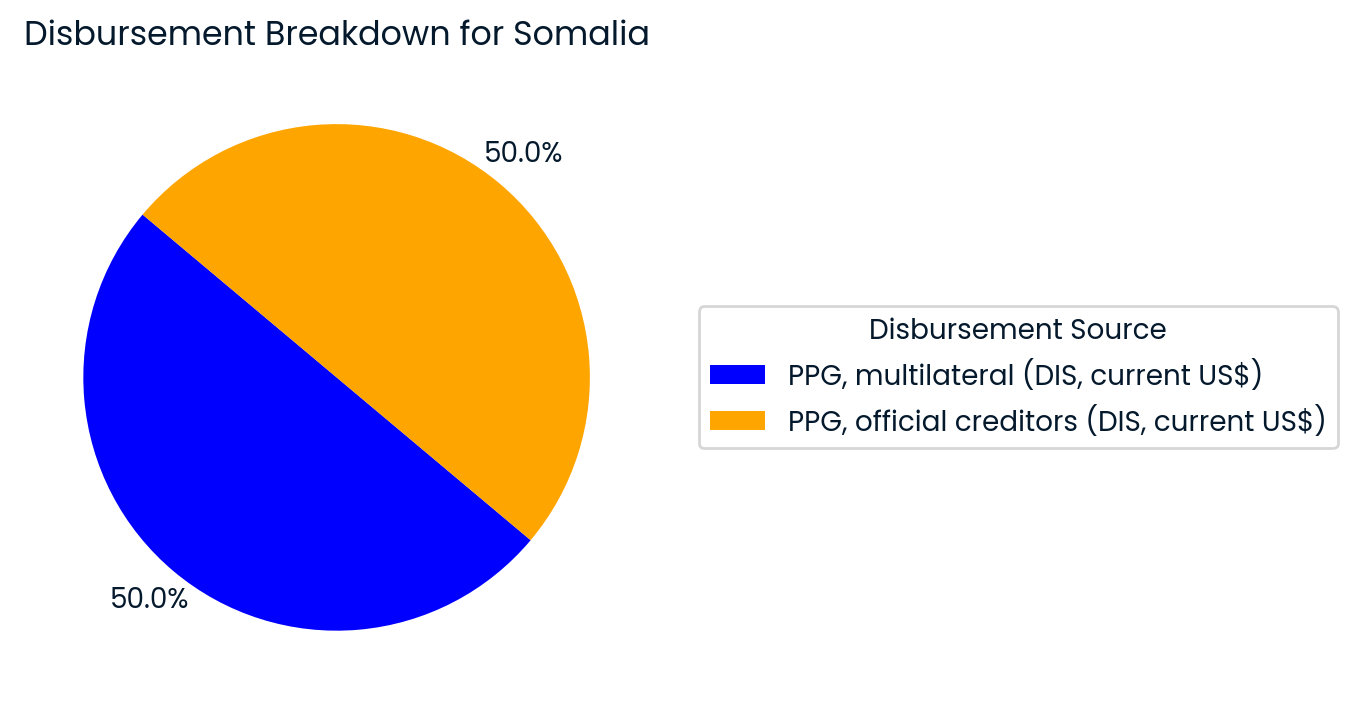

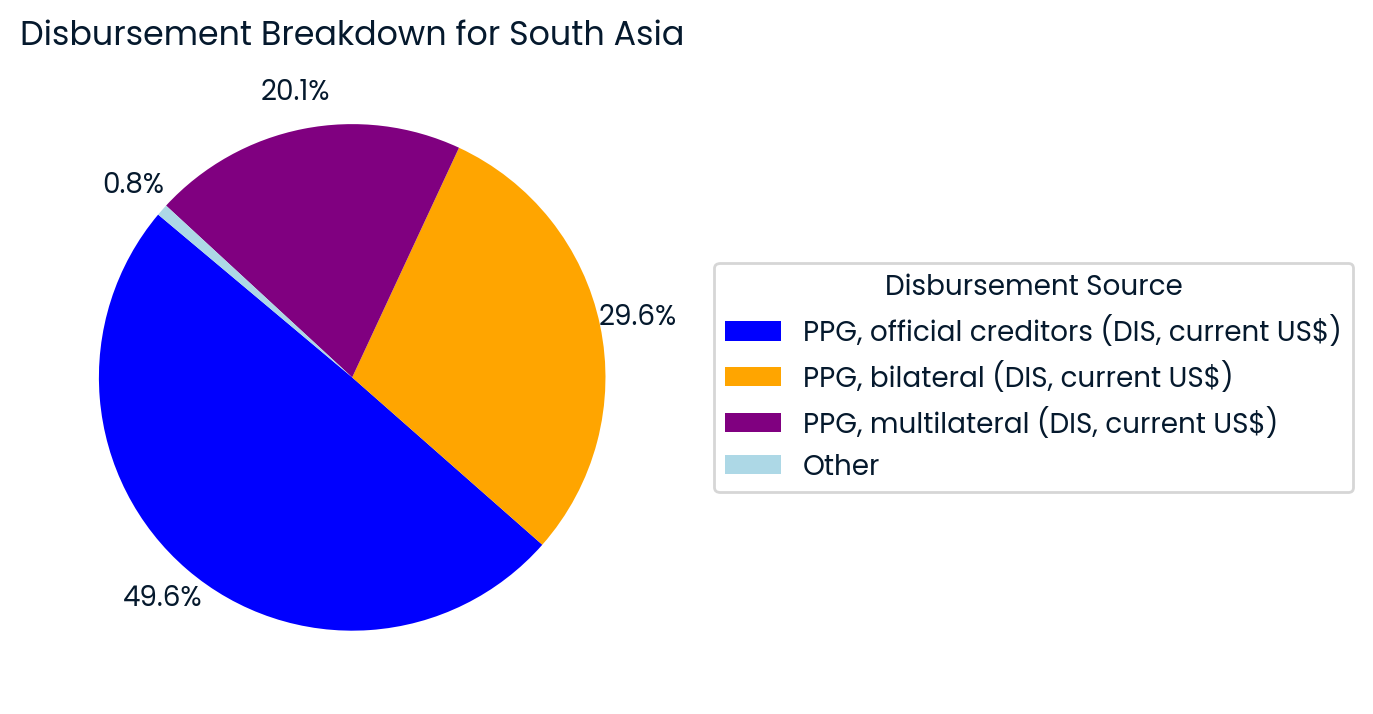

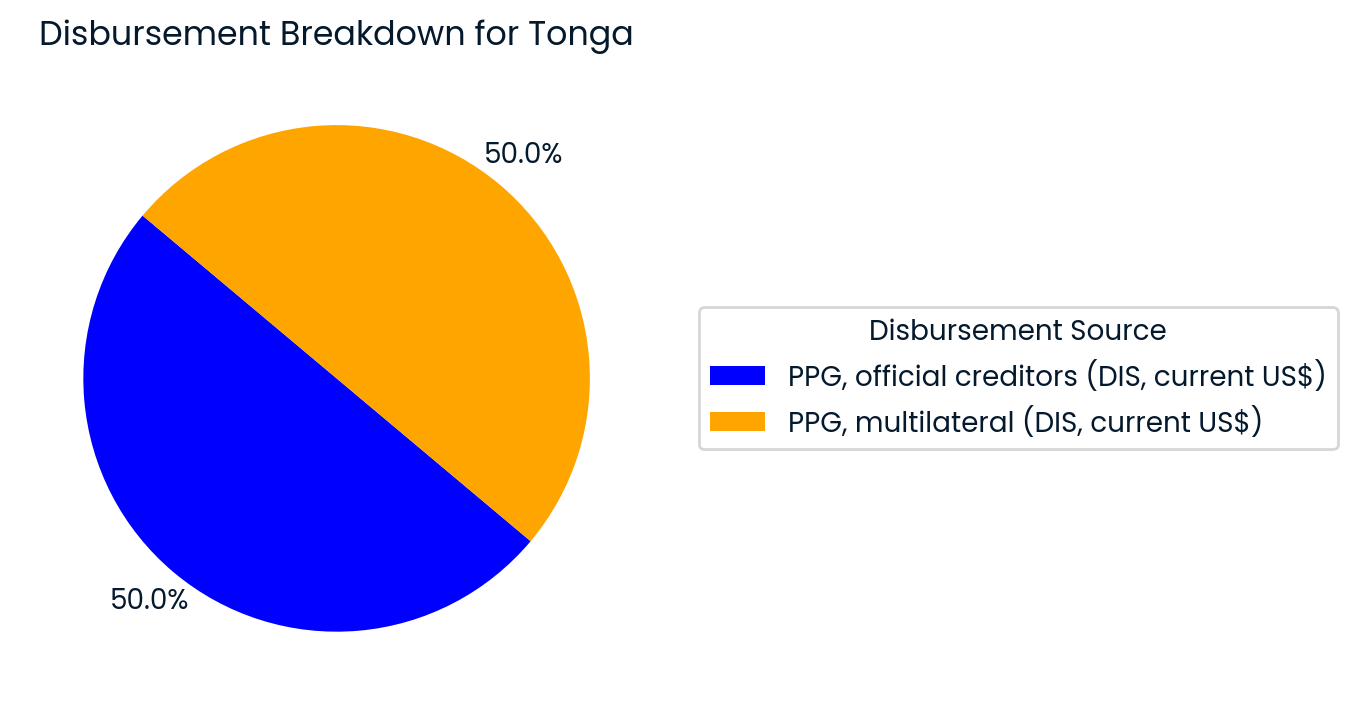

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_disbursement_pie_charts(disbursement_breakdown_df, threshold_percent=5):
    pie_colors = ['blue', 'orange', 'purple', 'lightblue', 'yellow', 'magenta', 'gray']

    countries = disbursement_breakdown_df['country_name'].unique()

    for country in countries:
        data = disbursement_breakdown_df[disbursement_breakdown_df['country_name'] == country].copy()
        total = data['total_disbursement'].sum()
        data['percent'] = 100 * data['total_disbursement'] / total

        # Split into large and small contributions
        large = data[data['percent'] >= threshold_percent]
        small = data[data['percent'] < threshold_percent]

        # Combine small into 'Other'
        if not small.empty:
            other_row = pd.DataFrame({
                'country_name': [country],
                'indicator_name': ['Other'],
                'total_disbursement': [small['total_disbursement'].sum()],
                'percent': [small['percent'].sum()]
            })
            data = pd.concat([large, other_row], ignore_index=True)

        # Sort by disbursement
        data = data.sort_values(by='total_disbursement', ascending=False)

        # Plot pie chart
        plt.figure(figsize=(7, 7))
        plt.pie(
            data['total_disbursement'],
            labels=None,
            autopct='%1.1f%%',
            pctdistance=1.15,
            colors=pie_colors[:len(data)],
            startangle=140,
            textprops={'fontsize': 10}
        )
        plt.legend(data['indicator_name'], title="Disbursement Source", bbox_to_anchor=(1.05, 0.5), loc='center left')
        plt.title(f'Disbursement Breakdown for {country}')
        plt.tight_layout()
        plt.show()
plot_disbursement_pie_charts(disbursement_breakdown_df)
